# Chapter 8: Calculation of Molecular Properties

## 8.2. Calculation of Potential Energy of Reaction Intermediates

Computational methods allows the calculation of potential energy of reaction intermediates such as cation, anion, and free radical.

### 8.2.1. Calculation of Potential Energy of Cations

In the following section, we will calculate the potential energies of different allyic cations:

In [1]:
# Import modules
import os
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from utils import View3DModel
import psi4
import py3Dmol
from tqdm import tqdm

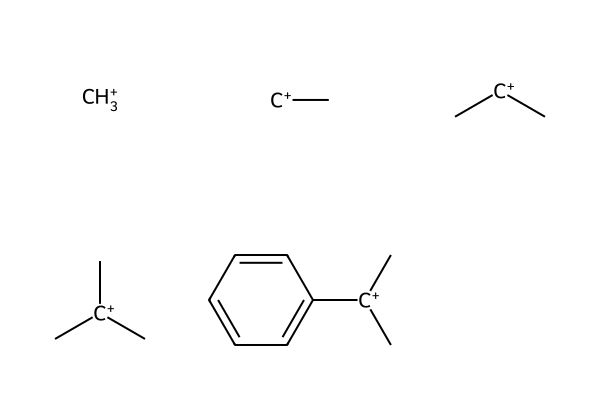

In [2]:
# Create the cation
cation1 = Chem.MolFromSmiles('[CH3+]')
cation2 = Chem.MolFromSmiles('[CH2+](C)')
cation3 = Chem.MolFromSmiles('[CH+](C)(C)')
cation4 = Chem.MolFromSmiles('[C+](C)(C)(C)')
cation5 = Chem.MolFromSmiles('[C+](C1=CC=CC=C1)(C)(C)')
cations = [cation1, cation2, cation3, cation4, cation5]

Draw.MolsToGridImage(cations)

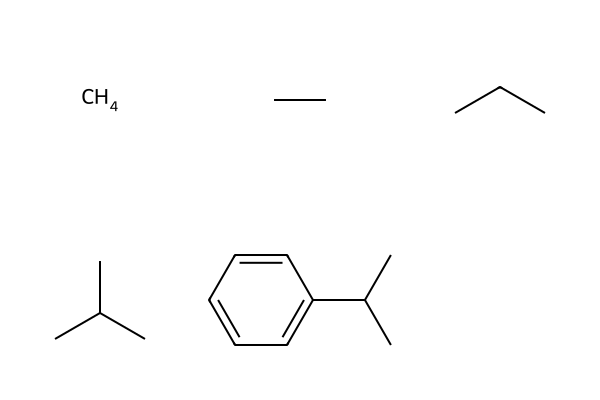

In [3]:
# Create the molecules
mol1 = Chem.MolFromSmiles('C')
mol2 = Chem.MolFromSmiles('CC')
mol3 = Chem.MolFromSmiles('C(C)(C)')
mol4 = Chem.MolFromSmiles('C(C)(C)(C)')
mol5 = Chem.MolFromSmiles('C(C1=CC=CC=C1)(C)C')
mols = [mol1, mol2, mol3, mol4, mol5]

Draw.MolsToGridImage(mols)

In [4]:
# Set the number of threads and memory limit
psi4.set_num_threads(16)
psi4.set_memory(16*1024*1024*1024) # 16 GB

17179869184

In [5]:
# Set calculation options
psi4.set_options({
    'BASIS': '6-31G*',
    'SCF_TYPE': 'DF',
    'REFERENCE': 'RHF'
})

In [6]:
# Define a function to generate xyz string with charge and multiplicity
def generate_xyz_string(mol, charge, multiplicity):
    # Get atom information
    atoms = mol.GetAtoms()
    xyz_lines = []
    for atom in atoms:
        pos = mol.GetConformer().GetAtomPosition(atom.GetIdx())
        xyz_lines.append(f"{atom.GetSymbol()} {pos.x} {pos.y} {pos.z}")

    # Construct the XYZ string
    xyz_string = f"{charge} {multiplicity}\n" + "\n".join(xyz_lines)
    return xyz_string

In [7]:
cation_energies = []
cation_wfns = []

# Optimize the geometries and calculate the energies for all cations
progress_bar = tqdm(cations)
for mol in progress_bar:
    smiles = Chem.MolToSmiles(mol)
    progress_bar.set_description(f'SMILES: {smiles}. Optimizing geometry...')
    
    # Prepare the molecule
    mol = Chem.AddHs(mol)
    Chem.rdDistGeom.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol, maxIters=200)
    
    # Write the geometry to XYZ string
    charge = 1  # For cation
    multiplicity = 1  # Singlet state
    xyz_string = generate_xyz_string(mol, charge, multiplicity)

    # Get the psi4 geometry
    geometry = psi4.geometry(xyz_string)
    
    # Run geometry optimization
    max_iters = 500
    energy, wfn = psi4.optimize('b3lyp', molecule=geometry, optking__geom_maxiter=max_iters, return_wfn=True)
    cation_energies.append(energy * psi4.constants.hartree2kcalmol)
    cation_wfns.append(wfn)

SMILES: [CH2+]C. Optimizing geometry...:  20%|████████▌                                  | 1/5 [00:03<00:12,  3.06s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.07e-03

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 5.70e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 5.99e-07

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Unable to completely converge to displaced geometry.
	RMS(dx):  3.509e-07 	Max(dx):  8.605e-07 	RMS(dq):  2.823e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.32e-06

SMILES: C[CH+]C. Optimizing geometry...:  40%|█████████████████▏                         | 2/5 [00:13<00:22,  7.40s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 6.55e-04

	Unable to completely converge to displaced geometry.
	RMS(dx):  4.986e-07 	Max(dx):  1.778e-06 	RMS(dq):  2.189e-04
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.19e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.93e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 8.08e-08

SMILES: C[C+](C)C. Optimizing geometry...:  60%|████████████████████████▌                | 3/5 [00:23<00:16,  8.45s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.47e-04

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.257e-06 	Max(dx):  5.746e-06 	RMS(dq):  7.845e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.84e-05

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.255e-06 	Max(dx):  3.578e-06 	RMS(dq):  2.828e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.10e-06

SMILES: C[C+](C)c1ccccc1. Optimizing geometry...:  80%|███████████████████████████▏      | 4/5 [00:37<00:10, 10.95s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  8.937e-07 	Max(dx):  2.901e-06 	RMS(dq):  9.726e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.31e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.679e-06 	Max(dx):  1.394e-05 	RMS(dq):  1.387e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.36e-05

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.804e-06 	Max(dx):  7.982e-06 	RMS(dq):  3.594e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.95e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  5.110e-06 	Max(dx):  2.882e-05 	RMS(dq):  4.002e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.49e-06

	Unable to compl

Optimizer: Optimization complete!


In [8]:
mol_energies = []
mol_wfns = []

# Optimize the geometries and calculate the energies for all molecules
progress_bar = tqdm(mols)
for mol in progress_bar:
    smiles = Chem.MolToSmiles(mol)
    progress_bar.set_description(f'SMILES: {smiles}. Optimizing geometry...')
    
    # Prepare the molecule
    mol = Chem.AddHs(mol)
    Chem.rdDistGeom.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol, maxIters=200)
    
    # Write the geometry to XYZ string
    xyz_string = Chem.MolToXYZBlock(mol)

    # Get the psi4 geometry
    geometry = psi4.geometry(xyz_string)
    
    # Run geometry optimization
    max_iters = 500
    energy, wfn = psi4.optimize('b3lyp', molecule=geometry, optking__geom_maxiter=max_iters, return_wfn=True)
    mol_energies.append(energy * psi4.constants.hartree2kcalmol)
    mol_wfns.append(wfn)

SMILES: CC. Optimizing geometry...:  20%|█████████▌                                      | 1/5 [00:03<00:12,  3.07s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.58e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.05e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.03e-07

SMILES: CCC. Optimizing geometry...:  40%|██████████████████▊                            | 2/5 [00:09<00:14,  4.87s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.96e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.77e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.93e-07

SMILES: CC(C)C. Optimizing geometry...:  60%|██████████████████████████▍                 | 3/5 [00:17<00:12,  6.22s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  1.099e-06 	Max(dx):  3.637e-06 	RMS(dq):  9.563e-07
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.56e-07

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 6.250e-02.
SMILES: CC(C)c1ccccc1. Optimizing geometry...:  80%|█████████████████████████████▌       | 4/5 [00:42<00:13, 13.97s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  1.210e-06 	Max(dx):  3.916e-06 	RMS(dq):  9.579e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.58e-05

	Unable to completely converge to displaced geometry.
	RMS(dx):  5.492e-06 	Max(dx):  1.606e-05 	RMS(dq):  1.465e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.46e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Unable to completely converge to displaced geometry.
	RMS(dx):  5.272e-06 	Max(dx):  1.785e-05 	RMS(dq):  1.384e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.35e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.678e-06 	Max(dx):  1.457e-05 	RMS(dq):  2.064e-06
	Previous geometry is

Optimizer: Optimization complete!


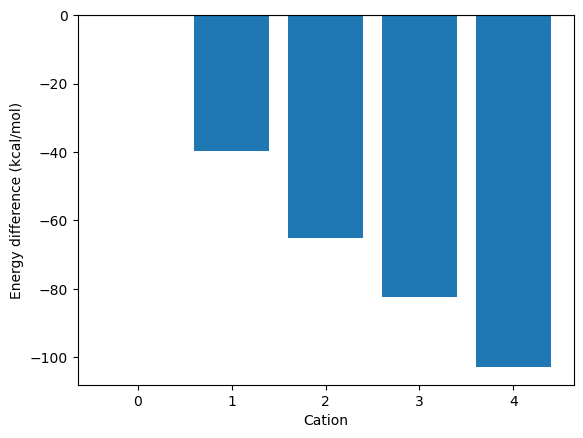

In [9]:
# Calculate the energy differences between the cations and the molecules
cation_energies = np.array(cation_energies)
mol_energies = np.array(mol_energies)
energy_diff = cation_energies - mol_energies

# Use methyl free radical as the reference
energy_diff = energy_diff - energy_diff[0]

# Plot the energy differences
x = range(len(energy_diff))
plt.bar(x, energy_diff)
plt.xlabel('Cation')
plt.ylabel('Energy difference (kcal/mol)')
plt.axhline(0, color='black')

### 8.2.2. Calculation of Potential Energy of Anion

In the following section, we will calculate the potential energies of different benzoic acids and benzoate anions in order to compare there acidity/basicity:

In [10]:
# Import modules
import os
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from utils import View3DModel, WriteXYZString # same as generate_xyz_string() function above
import psi4
import py3Dmol
from tqdm import tqdm

In [11]:
# Create the core molecules
core_acid_mol = Chem.MolFromSmiles('c1cc(C(=O)O)ccc1*')
core_base_mol = Chem.MolFromSmiles('c1cc(C(=O)[O-])ccc1*')

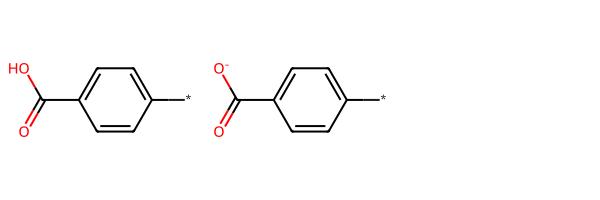

In [12]:
Draw.MolsToGridImage([core_acid_mol, core_base_mol])

In [13]:
# Define substituents
substituents = ['[H]', 'C', 'Cl', 'O', 'C(=O)C']

In [14]:
# Generate acids band bases
acids = []
bases = []

for substituent in substituents:
    # Create a copy of the core molecules
    core_acid_mol_copy = Chem.Mol(core_acid_mol)
    core_base_mol_copy = Chem.Mol(core_base_mol)

    # Replace a hydrogen atom with the substituent
    subst_mol = Chem.MolFromSmiles(substituent)
    subst_acid_mol_smiles = Chem.MolToSmiles(Chem.rdmolops.ReplaceSubstructs(core_acid_mol_copy, Chem.MolFromSmarts('[#0]'), subst_mol)[0])
    subst_base_mol_smiles = Chem.MolToSmiles(Chem.rdmolops.ReplaceSubstructs(core_base_mol_copy, Chem.MolFromSmarts('[#0]'), subst_mol)[0])
    acids.append(Chem.MolFromSmiles(subst_acid_mol_smiles))
    bases.append(Chem.MolFromSmiles(subst_base_mol_smiles))

[21:42:48] WARNING: not removing hydrogen atom without neighbors


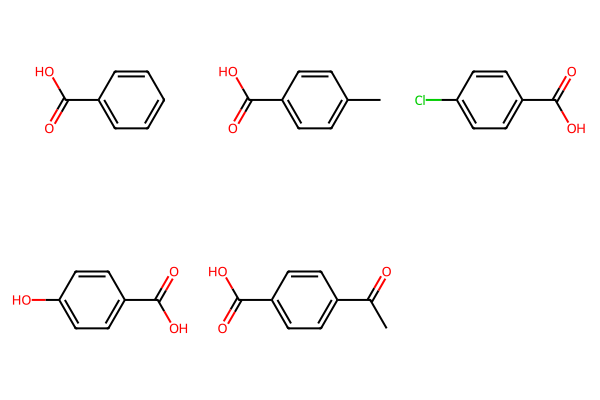

In [15]:
Draw.MolsToGridImage(acids)

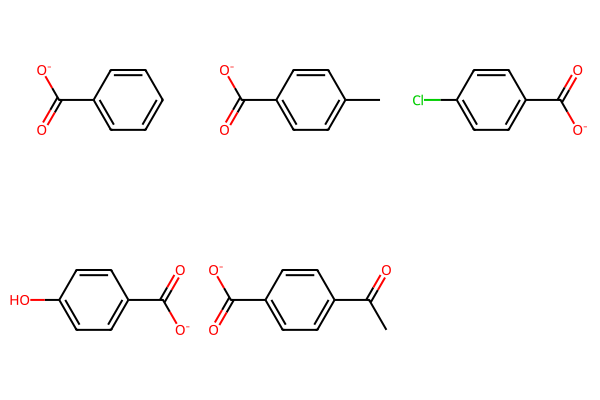

In [16]:
Draw.MolsToGridImage(bases)

In [17]:
# Set the number of threads and set memory limit
psi4.set_num_threads(32)
psi4.set_memory(16*1024*1024*1024) # 16 GB

17179869184

In [18]:
# Set calculation options
psi4.set_options({
    'BASIS': '6-31G*',
    'SCF_TYPE': 'DF',
    'REFERENCE': 'RHF'
})

In [19]:
acid_energies = []
acid_wfns = []

# Optimize the geometries and calculate the energies for all acids
progress_bar = tqdm(acids)
for mol in progress_bar:
    smiles = Chem.MolToSmiles(mol)
    progress_bar.set_description(f'SMILES: {smiles}. Optimizing geometry...')
    
    # Prepare the molecule
    mol = Chem.AddHs(mol)
    Chem.rdDistGeom.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol, maxIters=200)
    
    # Write the geometry to XYZ string
    xyz_string = Chem.MolToXYZBlock(mol)

    # Get the psi4 geometry
    geometry = psi4.geometry(xyz_string)
    
    # Run geometry optimization
    max_iters = 500
    energy, wfn = psi4.optimize('b3lyp', molecule=geometry, optking__geom_maxiter=max_iters, return_wfn=True)
    acid_energies.append(energy * psi4.constants.hartree2kcalmol)
    acid_wfns.append(wfn)

SMILES: O=C(O)c1ccccc1. Optimizing geometry...:   0%|                                            | 0/5 [00:00<?, ?it/s]	Unable to completely converge to displaced geometry.
	RMS(dx):  3.050e-07 	Max(dx):  1.202e-06 	RMS(dq):  7.750e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.75e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.196e-07 	Max(dx):  8.218e-07 	RMS(dq):  5.361e-07
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 5.34e-07

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.394e-06 	Max(dx):  4.637e-06 	RMS(dq):  2.052e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.79e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.874e-06 	Max(dx):  8.315e-06 	RMS(dq):  2.580e-06
	Unable to completely conv

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.51e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.64e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 1.875e-01.
SMILES: O=C(O)c1ccc(Cl)cc1. Optimizing geometry...:  40%|████████████▊                   | 2/5 [02:50<04:22, 87.55s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  2.116e-06 	Max(dx):  8.512e-06 	RMS(dq):  3.633e-06
	Unable to completely converge to displaced geometry.
	RMS(dx):  1.492e-06 	Max(dx):  4.937e-06 	RMS(dq):  1.905e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.68e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.127e-06 	Max(dx):  6.018e-06 	RMS(dq):  3.574e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.21e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.498e-06 	Max(dx):  6.287e-06 	RMS(dq):  4.077e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.38e-06

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Unable to completely

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  2.231e-07 	Max(dx):  7.541e-07 	RMS(dq):  4.626e-06
	Unable to completely converge to displaced geometry.
	RMS(dx):  3.004e-06 	Max(dx):  1.276e-05 	RMS(dq):  4.472e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.96e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.559e-06 	Max(dx):  9.958e-06 	RMS(dq):  3.468e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.36e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.277e-06 	Max(dx):  1.230e-05 	RMS(dq):  4.079e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.25e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  5.639e-06 	Max(dx):  2.075e-05 	RMS(dq):  9.410e-06
	Previous geometry is closer

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  8.127e-07 	Max(dx):  2.410e-06 	RMS(dq):  4.560e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.56e-05

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.401e-06 	Max(dx):  4.630e-06 	RMS(dq):  1.485e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.87e-07

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.862e-06 	Max(dx):  7.571e-06 	RMS(dq):  3.605e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.17e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.537e-06 	Max(dx):  8.906e-06 	RMS(dq):  4.246e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.79e-06

	Previous geomet

Optimizer: Optimization complete!


In [20]:
base_energies = []
base_wfns = []

# Optimize the geometries and calculate the energies for all bases
progress_bar = tqdm(bases)
for mol in progress_bar:
    smiles = Chem.MolToSmiles(mol)
    progress_bar.set_description(f'SMILES: {smiles}. Optimizing geometry...')
    
    # Prepare the molecule
    mol = Chem.AddHs(mol)
    Chem.rdDistGeom.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol, maxIters=200)
    
    # Write the geometry to XYZ string
    charge = -1  # For anion
    multiplicity = 1  # Singlet state
    xyz_string = WriteXYZString(mol, charge, multiplicity)

    # Get the psi4 geometry
    geometry = psi4.geometry(xyz_string)
    
    # Run geometry optimization
    max_iters = 500
    energy, wfn = psi4.optimize('b3lyp', molecule=geometry, optking__geom_maxiter=max_iters, return_wfn=True)
    base_energies.append(energy * psi4.constants.hartree2kcalmol)
    base_wfns.append(wfn)

SMILES: O=C([O-])c1ccccc1. Optimizing geometry...:   0%|                                         | 0/5 [00:00<?, ?it/s]	Unable to completely converge to displaced geometry.
	RMS(dx):  7.801e-07 	Max(dx):  2.099e-06 	RMS(dq):  3.572e-06
	Unable to completely converge to displaced geometry.
	RMS(dx):  2.208e-06 	Max(dx):  6.008e-06 	RMS(dq):  4.405e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.22e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.484e-06 	Max(dx):  1.183e-05 	RMS(dq):  4.440e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.52e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.688e-06 	Max(dx):  6.094e-06 	RMS(dq):  1.698e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.70e-05

	Previous geometry is clos

Optimizer: Optimization complete!


	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.62e-03

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.04e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 1.875e-01.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.58e-08

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.78e-09

SMILES: O=C([O-])c1ccc(Cl)cc1. Optimizing geometry...:  40%|███████████▌                 | 2/5 [03:09<04:51, 97.13s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  4.364e-07 	Max(dx):  1.796e-06 	RMS(dq):  2.810e-06
	Unable to completely converge to displaced geometry.
	RMS(dx):  4.529e-06 	Max(dx):  2.029e-05 	RMS(dq):  3.677e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.80e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.077e-06 	Max(dx):  5.346e-06 	RMS(dq):  2.300e-06
	Unable to completely converge to displaced geometry.
	RMS(dx):  2.140e-06 	Max(dx):  6.220e-06 	RMS(dq):  3.616e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.09e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.62e-04

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Unable to completely

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  5.890e-07 	Max(dx):  2.758e-06 	RMS(dq):  5.385e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 5.38e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.638e-06 	Max(dx):  5.396e-06 	RMS(dq):  5.046e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.55e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.857e-06 	Max(dx):  9.147e-06 	RMS(dq):  3.401e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.33e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.476e-06 	Max(dx):  4.341e-06 	RMS(dq):  4.616e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.50e-06

	Unable to compl

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  8.012e-07 	Max(dx):  2.523e-06 	RMS(dq):  3.867e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.87e-05

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.937e-06 	Max(dx):  9.947e-06 	RMS(dq):  4.978e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.92e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  2.585e-06 	Max(dx):  8.625e-06 	RMS(dq):  3.107e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.39e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.634e-06 	Max(dx):  1.573e-05 	RMS(dq):  3.564e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.29e-06

	Previous geomet

Optimizer: Optimization complete!


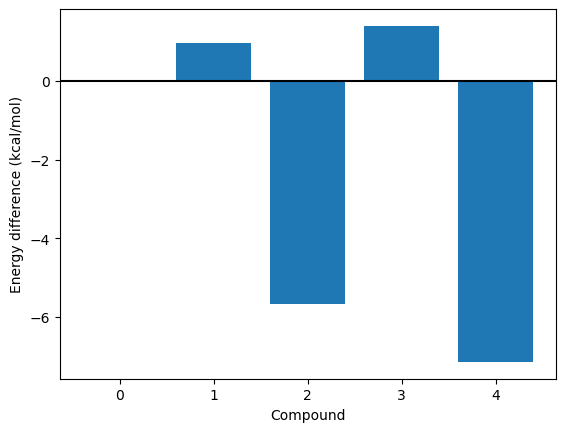

In [21]:
# Calculate the energy differences between the acids and the bases
acid_energies = np.array(acid_energies)
base_energies = np.array(base_energies)
energy_diff = base_energies - acid_energies

# Use benzoic acid as the reference
energy_diff = energy_diff - energy_diff[0]

# Plot the energy differences
x = range(len(energy_diff))
plt.bar(x, energy_diff)
plt.xlabel('Compound')
plt.ylabel('Energy difference (kcal/mol)')
plt.axhline(0, color='black')

### 8.2.3. Calculation of Potential Energy of Free Radicals

In the following section, we will calculate the potential energies of different free radical and compare their stability:

In [22]:
# Import modules
import os
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from utils import View3DModel, WriteXYZString
import psi4
import py3Dmol
from tqdm import tqdm

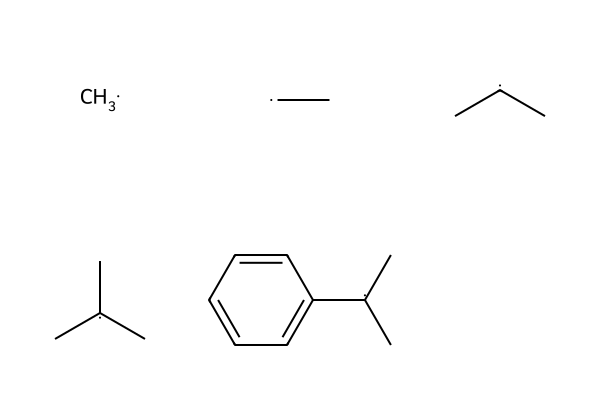

In [23]:
# Create the free radicals
radical1 = Chem.MolFromSmiles('[CH3]')
radical2 = Chem.MolFromSmiles('[CH2](C)')
radical3 = Chem.MolFromSmiles('[CH](C)(C)')
radical4 = Chem.MolFromSmiles('[C](C)(C)(C)')
radical5 = Chem.MolFromSmiles('[C](C1=CC=CC=C1)(C)(C)')
radicals = [radical1, radical2, radical3, radical4, radical5]

Draw.MolsToGridImage(radicals)

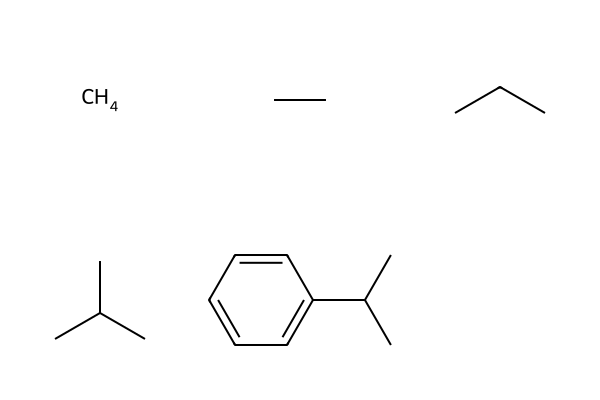

In [24]:
# Create the molecules
mol1 = Chem.MolFromSmiles('C')
mol2 = Chem.MolFromSmiles('CC')
mol3 = Chem.MolFromSmiles('C(C)(C)')
mol4 = Chem.MolFromSmiles('C(C)(C)(C)')
mol5 = Chem.MolFromSmiles('C(C1=CC=CC=C1)(C)C')
mols = [mol1, mol2, mol3, mol4, mol5]

Draw.MolsToGridImage(mols)

In [25]:
# Set the number of threads and set memory limit
psi4.set_num_threads(8)
psi4.set_memory(16*1024*1024*1024) # 16 GB

17179869184

In [26]:
# Set calculation options
psi4.set_options({
    'BASIS': '6-31G*',
    'SCF_TYPE': 'DF',
    'REFERENCE': 'UHF' # Use UHF or ROHF for doublet state
})

In [27]:
radical_energies = []
radical_wfns = []

# Optimize the geometries and calculate the energies for all free radicals
progress_bar = tqdm(radicals)
for mol in progress_bar:
    smiles = Chem.MolToSmiles(mol)
    progress_bar.set_description(f'SMILES: {smiles}. Optimizing geometry...')
    
    # Prepare the molecule
    mol = Chem.AddHs(mol)
    Chem.rdDistGeom.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol, maxIters=200)
    
    # Write the geometry to XYZ string
    charge = 0  # For free radical
    multiplicity = 2  # Doublet state
    xyz_string = WriteXYZString(mol, charge, multiplicity)

    # Get the psi4 geometry
    geometry = psi4.geometry(xyz_string)
    
    # Run geometry optimization
    max_iters = 500
    energy, wfn = psi4.optimize('b3lyp', molecule=geometry, optking__geom_maxiter=max_iters, return_wfn=True)
    radical_energies.append(energy * psi4.constants.hartree2kcalmol)
    radical_wfns.append(wfn)

SMILES: [CH3]. Optimizing geometry...:   0%|                                                     | 0/5 [00:00<?, ?it/s]	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 6.78e-03

	Change in internal coordinate of 5.60e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 5.25e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 6.89e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 6.43e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 8.07e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.59e-07

SMILES: [CH2]C. Optimizing geometry...:  20%|████████▊                                  

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.93e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 5.62e-07

SMILES: C[CH]C. Optimizing geometry...:  40%|█████████████████▌                          | 2/5 [00:28<00:45, 15.30s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.03e-04

SMILES: C[C](C)C. Optimizing geometry...:  60%|█████████████████████████▏                | 3/5 [01:03<00:48, 24.12s/it]

Optimizer: Optimization complete!


	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Denominators (dg)(dq) or (dq)(dq) are very small.
	Skipping Hessian update for step 10.
	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 6.250e-02.
	Denominators (dg)(dq) or (dq)(dq) are very small.
	Skipping Hessian update for step 11.
	Denominators (dg)(dq) or (dq)(dq) are very small.
	Skipping Hessian update for step 10.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.00e-09

SMILES: C[C](C)c1ccccc1. Optimizing geometry...:  80%|████████████████████████████       | 4/5 [02:05<00:39, 39.14s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  2.087e-06 	Max(dx):  1.150e-05 	RMS(dq):  2.322e-03
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.32e-03

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.454e-06 	Max(dx):  1.197e-05 	RMS(dq):  6.238e-04
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 6.24e-04

	Unable to completely converge to displaced geometry.
	RMS(dx):  5.008e-06 	Max(dx):  1.687e-05 	RMS(dq):  2.488e-04
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.49e-04

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.903e-06 	Max(dx):  1.569e-05 	RMS(dq):  8.621e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 8.62e-05

	Unable to compl

Optimizer: Optimization complete!


In [28]:
# Set calculation options
psi4.set_options({
    'REFERENCE': 'RHF' # Use RHF for singlet state
})

In [29]:
mol_energies = []
mol_wfns = []

# Optimize the geometries and calculate the energies for all molecules
progress_bar = tqdm(mols)
for mol in progress_bar:
    smiles = Chem.MolToSmiles(mol)
    progress_bar.set_description(f'SMILES: {smiles}. Optimizing geometry...')
    
    # Prepare the molecule
    mol = Chem.AddHs(mol)
    Chem.rdDistGeom.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol, maxIters=200)
    
    # Write the geometry to XYZ string
    xyz_string = Chem.MolToXYZBlock(mol)

    # Get the psi4 geometry
    geometry = psi4.geometry(xyz_string)
    
    # Run geometry optimization
    max_iters = 500
    energy, wfn = psi4.optimize('b3lyp', molecule=geometry, optking__geom_maxiter=max_iters, return_wfn=True)
    mol_energies.append(energy * psi4.constants.hartree2kcalmol)
    mol_wfns.append(wfn)

SMILES: CC. Optimizing geometry...:  20%|█████████▌                                      | 1/5 [00:03<00:13,  3.28s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.58e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.05e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.03e-07

SMILES: CCC. Optimizing geometry...:  40%|██████████████████▊                            | 2/5 [00:09<00:15,  5.12s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.96e-04

	Unable to completely converge to displaced geometry.
	RMS(dx):  1.612e-06 	Max(dx):  5.312e-06 	RMS(dq):  3.100e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.53e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.70e-06

SMILES: CC(C)C. Optimizing geometry...:  60%|██████████████████████████▍                 | 3/5 [00:17<00:13,  6.53s/it]

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.68e-07

SMILES: CC(C)c1ccccc1. Optimizing geometry...:  80%|█████████████████████████████▌       | 4/5 [00:33<00:09,  9.97s/it]

Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  6.808e-07 	Max(dx):  2.666e-06 	RMS(dq):  9.579e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.58e-05

	Unable to completely converge to displaced geometry.
	RMS(dx):  3.143e-06 	Max(dx):  8.316e-06 	RMS(dq):  1.455e-05
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.45e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to 2.500e-01.
	Unable to completely converge to displaced geometry.
	RMS(dx):  4.125e-06 	Max(dx):  2.181e-05 	RMS(dq):  3.724e-06
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.61e-06

	Unable to completely converge to displaced geometry.
	RMS(dx):  9.354e-07 	Max(dx):  3.751e-06 	RMS(dq):  3.366e-06
	Previous geometry is

Optimizer: Optimization complete!


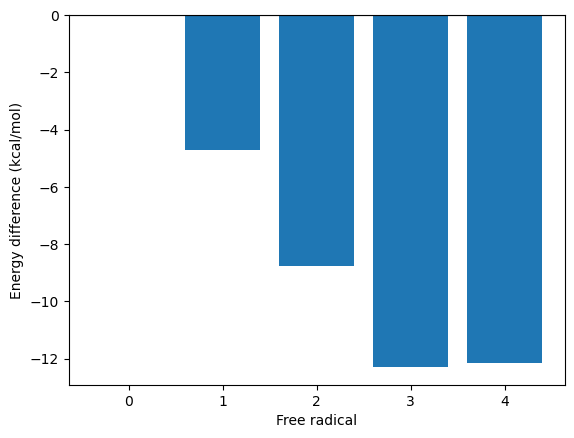

In [30]:
# Calculate the energy differences between the free radicals and the molecules
radical_energies = np.array(radical_energies)
mol_energies = np.array(mol_energies)
energy_diff = radical_energies - mol_energies

# Use methyl free radical as the reference
energy_diff = energy_diff - energy_diff[0]

# Plot the energy differences
x = range(len(energy_diff))
plt.bar(x, energy_diff)
plt.xlabel('Free radical')
plt.ylabel('Energy difference (kcal/mol)')
plt.axhline(0, color='black')